In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from feature import (
    make_stft_extractor,
    make_mfcc_extractor
)

from testing import(
    load_model_config,
    load_all_template_features_new,
    load_raven_selection_table,
    get_exclusion_intervals,
    detection_pipeline,
    match_detections,
    compute_pr_curve_alpha_new,
    compute_average_precision,
    plot_pr_curve,
    plot_detection_spectrograms
)
from calibration import(
    frame_hop_len
)

In [2]:
RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")

DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")

In [3]:
#editable variables
feat_method = "mfcc"
n_temps = 5
alpha_max = 3.0
n_hours = 72
t_max = n_hours * 3600.0


In [4]:
#download relevent calibration info
cfg = load_model_config(RESULTS / f"model_config_{feat_method}_{n_temps}.json")

feat_method_test = cfg["feature"]["method"]
fs_new = cfg["feature"]["fs_new"]
feat_frame_length = cfg["feature"]["frame_len"]
vote_frac = cfg["best_vote_frac"]
n_temps_test = cfg["n_temps"]
n_calib = cfg["n_calib"]

call_thresholds = cfg["thresholds"]      # {"st": ..., "mt": ..., "bt": ...}
st_threshold = call_thresholds["st"]
mt_threshold = call_thresholds["mt"]
bt_threshold = call_thresholds["bt"]

# Rebuild the extractor exactly as it was during calibration
if feat_method == "stft":
    extractor = make_stft_extractor(frame_dur=feat_frame_length)
elif feat_method == "mfcc":
    extractor = make_mfcc_extractor(frame_dur=feat_frame_length)

if feat_method_test == feat_method and n_temps_test == n_temps:
    print("Passed download test")

print(f"{feat_method_test}, fs_new = {fs_new}, frame len = {feat_frame_length}, vote frac = {vote_frac}, n_temps = {n_temps_test}, n_calib = {n_calib}")
print(f"st: {st_threshold}, mt: {mt_threshold}, bt: {bt_threshold}")

Passed download test
mfcc, fs_new = 1000, frame len = 0.384, vote frac = 0.2, n_temps = 5, n_calib = 10
st: 17.725710673634406, mt: 22.697946026316753, bt: 19.21476924299729


In [5]:
hop_s = frame_hop_len(extractor, fs_new)
print(hop_s)

min_sep_s = 2*feat_frame_length
print(min_sep_s)

0.096
0.768


In [6]:
st_feats, mt_feats, bt_feats = load_all_template_features_new(
    results_dir=RESULTS_29,
    file_label="20230429_Templates",
    recording_label="20230429_102841",
    extractor=extractor,
    n_temps=n_temps,
    fs_new=fs_new,
)

In [7]:
raven_table = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
td_intervals = get_exclusion_intervals(raven_table, exclude_labels=("td",), pad=0.1)

In [8]:
starts, ends, scaled_costs, labels = detection_pipeline(
    audio_file=DATA_22 / "20230422_171301.wav",
    n_hours=n_hours,
    st_feats=st_feats, mt_feats=mt_feats, bt_feats=bt_feats,
    st_threshold=st_threshold, mt_threshold=mt_threshold, bt_threshold=bt_threshold,
    exclude_intervals=td_intervals,
    extractor=extractor, fs_new=fs_new, vote_frac=vote_frac,
    hop_s=hop_s, frame_s=feat_frame_length,
    min_sep_s=min_sep_s, alpha_max=alpha_max,
)

Processing hour 1 of 72: 4 calls detected at the calibrated thresholds
Processing hour 2 of 72: 0 calls detected at the calibrated thresholds
Processing hour 3 of 72: 3 calls detected at the calibrated thresholds
Processing hour 4 of 72: 0 calls detected at the calibrated thresholds
Processing hour 5 of 72: 0 calls detected at the calibrated thresholds
Processing hour 6 of 72: 1 calls detected at the calibrated thresholds
Processing hour 7 of 72: 1 calls detected at the calibrated thresholds
Processing hour 8 of 72: 0 calls detected at the calibrated thresholds
Processing hour 9 of 72: 0 calls detected at the calibrated thresholds
Processing hour 10 of 72: 0 calls detected at the calibrated thresholds
Processing hour 11 of 72: 0 calls detected at the calibrated thresholds
Processing hour 12 of 72: 0 calls detected at the calibrated thresholds
Processing hour 13 of 72: 0 calls detected at the calibrated thresholds
Processing hour 14 of 72: 0 calls detected at the calibrated thresholds
P

In [9]:
raven_table_no_td = [
    g for g in raven_table 
    if g["label"] not in ("td",) and g["start"] < t_max
]

is_call = scaled_costs <= 1.0
calls = [(float(s), float(e), lab) for s, e, lab in zip(starts[is_call], ends[is_call], labels[is_call])]

tp_det, fp, tp_calls, fn, false_pos, false_neg = match_detections(calls, raven_table_no_td)
print(f"deployed: calls={len(calls)}  P={tp_det/(tp_det+fp):.3f}  R={tp_calls/(tp_calls+fn):.3f}")

deployed: calls=26633  P=0.057  R=0.926


alpha=1: P=0.057  R=0.926   (should match the deployed line above)


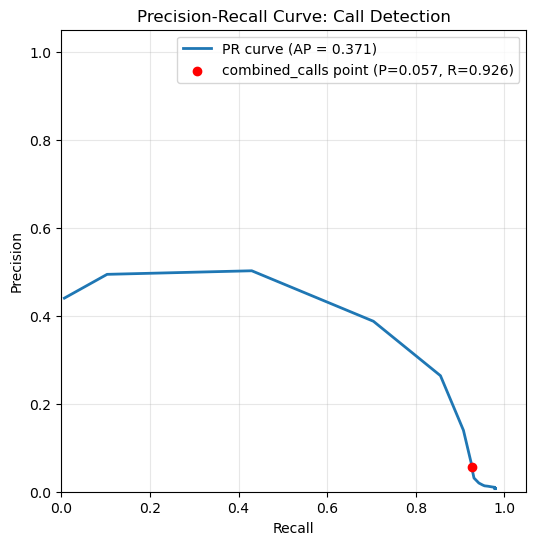

In [10]:
alphas = np.unique(np.append(np.linspace(0.1, alpha_max, 40), 1.0))
p1, r1, used = compute_pr_curve_alpha_new(starts, ends, scaled_costs, labels, raven_table_no_td, alphas)

i1 = np.argmin(np.abs(used - 1.0))
print(f"alpha=1: P={p1[i1]:.3f}  R={r1[i1]:.3f}   (should match the deployed line above)")

ap = compute_average_precision(p1, r1)
plot_pr_curve(p1, r1, ap=ap, marked_point=(p1[i1], r1[i1]))

False positives: 25113
  overlap an already-matched call (duplicates): 0.0%
  within 2 s of a labelled call:               2.9%
  more than 2 s from any call (background):    97.1%


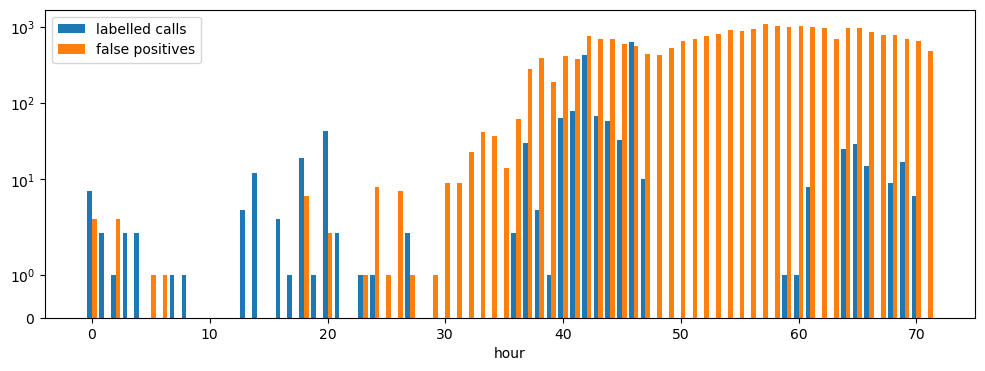

In [11]:
gt_s = np.array([g["start"] for g in raven_table_no_td])
gt_e = np.array([g["end"] for g in raven_table_no_td])
gaps = np.array([np.maximum(0, np.maximum(gt_s - e, s - gt_e)).min() for s, e, _ in false_pos])
print(f"False positives: {len(gaps)}")
print(f"  overlap an already-matched call (duplicates): {(gaps == 0).mean():.1%}")
print(f"  within 2 s of a labelled call:               {((gaps > 0) & (gaps < 2)).mean():.1%}")
print(f"  more than 2 s from any call (background):    {(gaps >= 2).mean():.1%}")

det_s = np.array([s for s, _, _ in calls])
fp_s = np.array([s for s, _, _ in false_pos])

hrs = np.arange(n_hours)
gt_h = np.bincount((gt_s // 3600).astype(int), minlength=n_hours)[:n_hours]
det_h = np.bincount((det_s // 3600).astype(int), minlength=n_hours)[:n_hours]
fp_h = np.bincount((fp_s // 3600).astype(int), minlength=n_hours)[:n_hours]

plt.figure(figsize=(12, 4))
plt.bar(hrs - 0.2, gt_h, width=0.4, label="labelled calls")
plt.bar(hrs + 0.2, fp_h, width=0.4, label="false positives")
plt.yscale("symlog")
plt.xlabel("hour")
plt.legend()
plt.show()


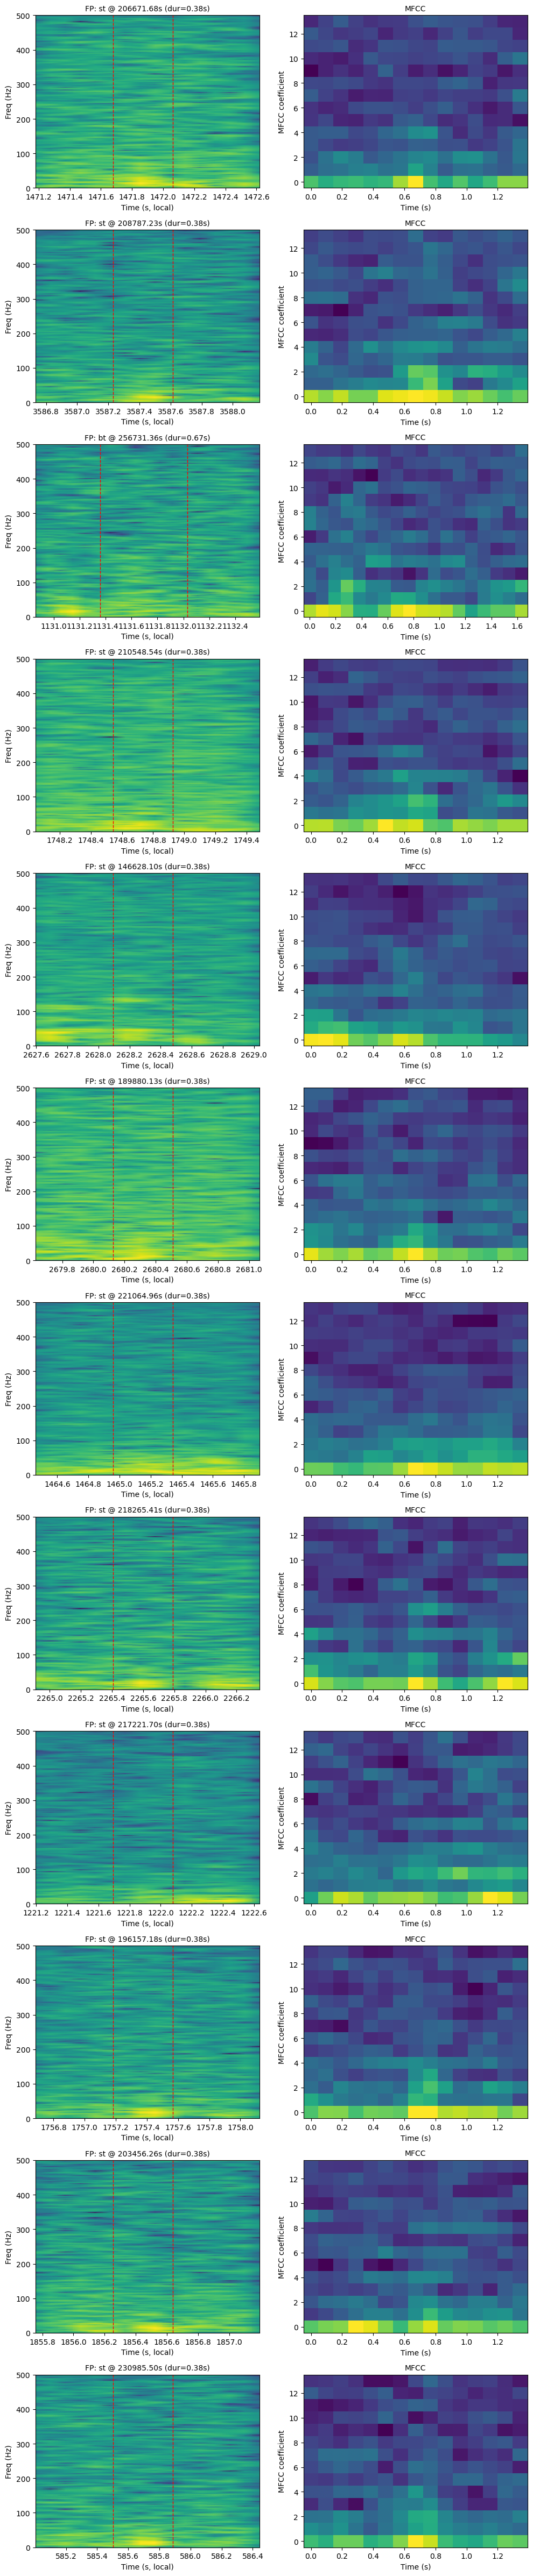

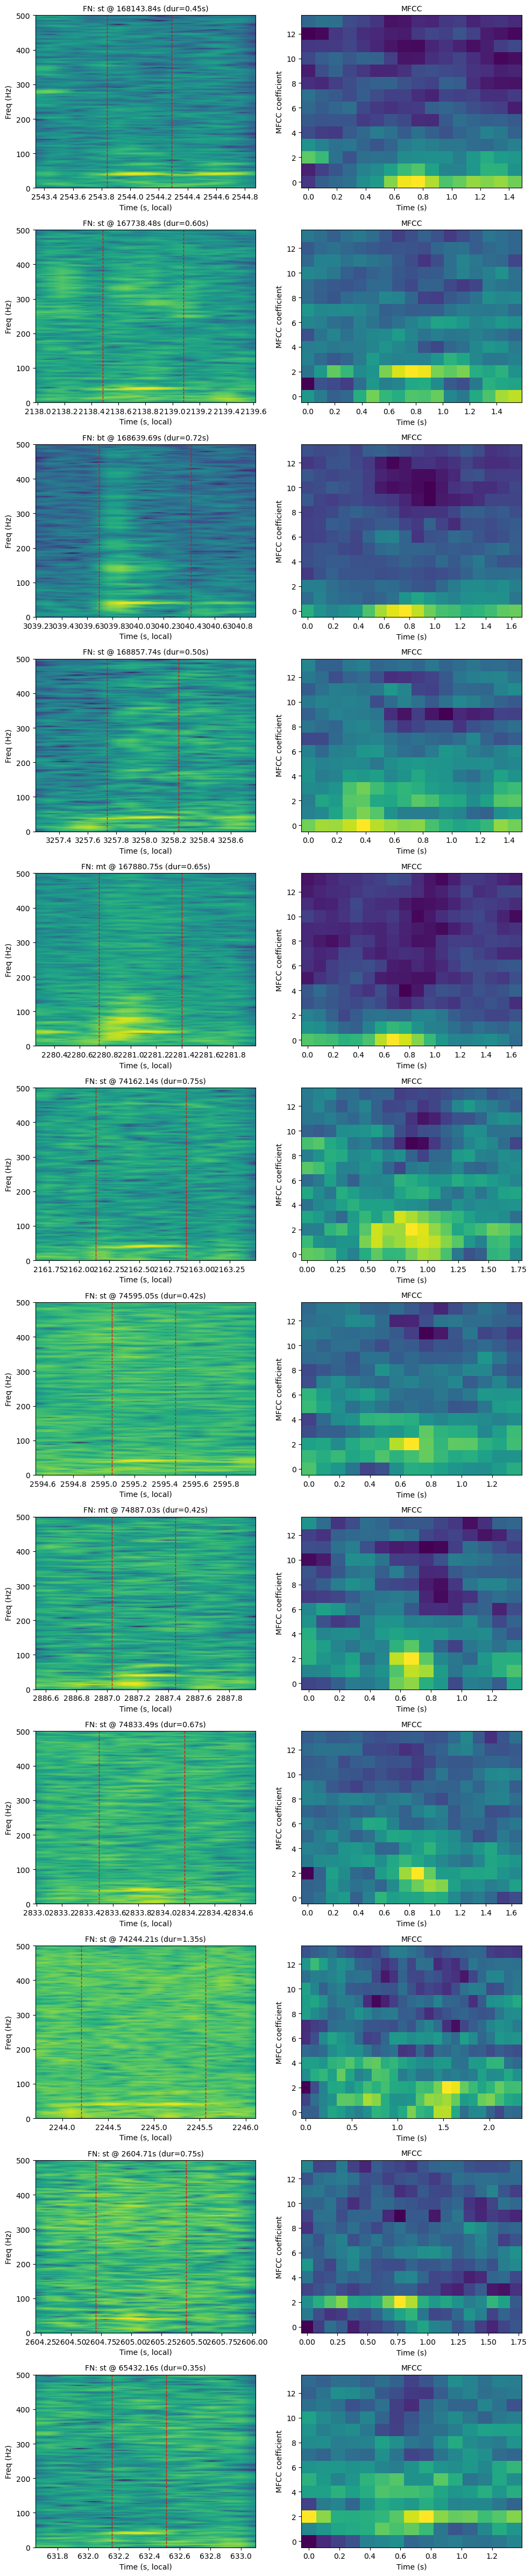

In [12]:
plot_detection_spectrograms(
    false_pos,
    DATA_22 / "20230422_171301.wav",
    fs_new=fs_new,
    framelength=int(fs_new * feat_frame_length),
    n_examples=12,
    title_prefix="FP",
    extractor = extractor,
    feat_method = feat_method,
    noverlap = None
)

fn_as_tuples = [(g["start"], g["end"], g["label"]) for g in false_neg]
plot_detection_spectrograms(
    fn_as_tuples,
    DATA_22 / "20230422_171301.wav",
    fs_new=fs_new,
    framelength=int(fs_new * feat_frame_length),
    n_examples=12,
    title_prefix="FN",
    extractor = extractor,
    feat_method = feat_method,
    noverlap = None
)